# Gly Registration Comparison

This notebook compares two approaches for mapping the raw MRSI Glycine (Gly) map into T1w space.

---

## Pipeline 1 — Our total pipeline (FreeSurfer Reg-17b, `-FSMask` variant)

**Goal:** bring every MRSI metabolite map into the downsampled T1w space by inverting a rigid T1w→MRSI registration.

### Step-by-step

1. **T1w skull stripping (FreeSurfer SynthStrip)**
   The full-resolution T1w (`acq-UNIDEND_T1w`) is skull-stripped with FreeSurfer's `mri_synthstrip`, producing:
   - `acq-UNIDEND_T1w_brain_synthstrip.nii` — brain-only T1w image
   - `acq-UNIDEND_T1w_brainmask_synthstrip.nii` — binary brain mask

2. **Downsample the FreeSurfer brain + mask to MRSI resolution**
   Both the skull-stripped T1w and its binary mask are resampled to the MRSI voxel grid (~3 mm, 74×74×37) using `nibabel.resample_from_to` (order=1 for brain, order=0 for mask).
   These become the **moving image** and **moving mask** for the registration step.

3. **Reorient MRSI water signal to RAS**
   The raw MRSI water channel is reoriented to RAS canonical orientation with FSL `fslreorient2std`.
   A binary mask is then derived from it with hole-filling (`fill_mask_holes`) → `WaterSignalRASMask`.
   This mask becomes the **fixed mask** for the registration step (restricts the metric computation to voxels where there is actual MRSI signal).

4. **Rigid registration: FreeSurfer DS T1w → MRSI sum map (Reg-17b)**
   `antsRegistration` is called with:
   - **Fixed image:** RAS MRSI all-metabolite sum map (`AllMetabSumRAS`)
   - **Moving image:** FreeSurfer downsampled skull-stripped T1w (`acq-MRSIres_desc-BrainSynthstrip_T1w`)
   - **Fixed mask:** water signal binary mask → only MRSI voxels with signal contribute to the metric
   - **Moving mask:** FreeSurfer downsampled brain binary mask → only brain voxels of T1w contribute
   - **Transform:** `Rigid[0.1]` (6 DOF)
   - **Metric:** Mattes Mutual Information (32 bins, 80% random sampling)
   - **Convergence:** 1000×500 iterations with 1e-6 threshold, shrink 2×1, smoothing 1×0 vox
   - **Initial transform:** center-of-mass alignment `[fixed, moving, 1]`

   The saved `.mat` file (`_fwdtransform.mat`) encodes the **forward direction: T1w → MRSI space**.

5. **Apply inverted transform to each metabolite map (including Gly)**
   `antsApplyTransforms` is called with the flag `[transform.mat,1]` — the `,1` instructs ANTs to **invert** the affine on the fly, effectively applying the **MRSI → T1w** direction to the metabolite map.
   - **Input (moving):** raw Gly map in MRSI space (`acq-OrigRes_desc-Gly_mrsi.nii.gz`)
   - **Reference (fixed):** FreeSurfer DS skull-stripped T1w (sets the output grid: T1w space, MRSI voxel size ~3 mm)
   - **Transform:** `[T1w→MRSI affine, inverted]`
   - **Output:** `acq-MRSIres_desc-GlyReg17-FSMask_T1w.nii.gz` — Gly in T1w space at MRSI resolution

---

## Pipeline 2 — Toolbox ANTs SyN (MRSI → T1w, forward)

**Goal:** bring the raw MRSI data into T1w space using a full diffeomorphic (SyN) warp computed directly in the forward direction by the mrsitoolbox.

### Step-by-step

1. **MRSI → T1w SyN registration (run by mrsitoolbox)**
   The toolbox runs `antsRegistration` with `SyN` (symmetric diffeomorphic) transform:
   - **Fixed image:** T1w brain
   - **Moving image:** MRSI image (signal map)
   - **Direction:** forward = MRSI → T1w
   - Two transform files are saved:
     - `sub-01_ses-01_desc-mrsi_to_t1w.affine.mat` — linear affine component
     - `sub-01_ses-01_desc-mrsi_to_t1w.syn.nii.gz` — non-linear deformation field (warp)

2. **Apply forward transform to raw Gly map (done here in the notebook)**
   `ants.apply_transforms` is called with the two transforms in order `[syn.nii.gz, affine.mat]` (ANTs convention: last applied first, so affine is applied first, then the warp):
   - **Fixed (target grid):** T1w background synthstrip image (full resolution 224×272×288, ~1 mm) for cell 3; or the `GlyReg17-FSMask` image (74×74×37, ~3 mm) for cell 6
   - **Moving:** raw Gly map in MRSI space
   - **Interpolator:** linear
   - **Output:** Gly warped into T1w space

---

## Key difference between the two pipelines

| | Our pipeline (Reg-17b) | Toolbox SyN |
|---|---|---|
| **Registration direction** | T1w → MRSI (inverted at application) | MRSI → T1w (forward) |
| **Transform type** | Rigid (6 DOF affine) | Rigid affine + SyN non-linear warp |
| **Fixed mask** | MRSI water signal binary mask | (toolbox internal) |
| **Moving mask** | FreeSurfer skull-strip binary mask | (toolbox internal) |
| **Output grid** | T1w space, MRSI voxel size (~3 mm) | Depends on fixed image chosen |
| **Gly source** | `final_reg/GlyReg17-FSMask_T1w.nii.gz` (pre-computed) | Applied on-the-fly in this notebook |

In [2]:
import os
from pathlib import Path

import ants
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.processing import resample_from_to

ROOT = Path('/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction')
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'output'
FINAL_REG_DIR = OUTPUT_DIR / 'final_reg'
TRANSFORM_DIR = DATA_DIR / 'bids' / 'derivatives' / 'transforms' / 'ants' / 'sub-01' / 'ses-01' / 'mrsi'
RAW_MRS_DIR = DATA_DIR / 'bids' / 'sub-01' / 'ses-01' / 'mrs'

FS_GLY_PATH = FINAL_REG_DIR / 'sub-01_ses-01_acq-MRSIres_desc-GlyReg17-FSMask_T1w.nii.gz'
TOOLBOX_GLY_SOURCE = RAW_MRS_DIR / 'sub-01_ses-01_acq-OrigRes_desc-Gly_mrsi.nii.gz'
TOOLBOX_SYN = TRANSFORM_DIR / 'sub-01_ses-01_desc-mrsi_to_t1w.syn.nii.gz'
TOOLBOX_AFFINE = TRANSFORM_DIR / 'sub-01_ses-01_desc-mrsi_to_t1w.affine.mat'

BACKGROUND_CANDIDATES = [
    OUTPUT_DIR / 'sub-01_ses-01_acq-UNIDEND_T1w_brain_synthstrip.nii',
    OUTPUT_DIR / 'sub-01_ses-01_acq-FullRes_desc-Brain_T1w.nii.gz',
    DATA_DIR / 'bids' / 'sub-01' / 'ses-01' / 'anat' / 'sub-01_ses-01_acq-UNIDEN_T1w.nii',
]

background_path = next((path for path in BACKGROUND_CANDIDATES if path.exists()), None)
if background_path is None:
    raise FileNotFoundError('No T1w background image found.')

required_paths = [FS_GLY_PATH, TOOLBOX_GLY_SOURCE, TOOLBOX_SYN, TOOLBOX_AFFINE, background_path]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

print('Background:', background_path)
print('Reg-17 FS Gly:', FS_GLY_PATH)
print('Toolbox Gly source:', TOOLBOX_GLY_SOURCE)
print('Toolbox transforms:', TOOLBOX_SYN, TOOLBOX_AFFINE)

Background: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/sub-01_ses-01_acq-UNIDEND_T1w_brain_synthstrip.nii
Reg-17 FS Gly: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/output/final_reg/sub-01_ses-01_acq-MRSIres_desc-GlyReg17-FSMask_T1w.nii.gz
Toolbox Gly source: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/bids/sub-01/ses-01/mrs/sub-01_ses-01_acq-OrigRes_desc-Gly_mrsi.nii.gz
Toolbox transforms: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/bids/derivatives/transforms/ants/sub-01/ses-01/mrsi/sub-01_ses-01_desc-mrsi_to_t1w.syn.nii.gz /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/data/bids/derivatives/transforms/ants/sub-01/ses-01/mrsi/sub-01_ses-01_desc-mrsi_to_t1w.affine.mat


In [3]:
def norm_image(data: np.ndarray) -> np.ndarray:
    data = np.asarray(data, dtype=np.float32)
    pos = data[np.isfinite(data) & (data > 0)]
    if pos.size == 0:
        return np.zeros_like(data, dtype=np.float32)
    scale = np.nanpercentile(pos, 99)
    if scale <= 0:
        return np.zeros_like(data, dtype=np.float32)
    return np.clip(data / float(scale), 0.0, 1.0)

def orthogonal_slices(volume: np.ndarray):
    mid = [dim // 2 for dim in volume.shape]
    return [
        volume[:, :, mid[2]],
        volume[:, mid[1], :],
        volume[mid[0], :, :],
    ]

background_img = nib.as_closest_canonical(nib.load(str(background_path)))
background_data = norm_image(background_img.get_fdata())

fs_gly_img = nib.as_closest_canonical(nib.load(str(FS_GLY_PATH)))
fs_gly_on_background = resample_from_to(fs_gly_img, background_img, order=1)
fs_gly_data = norm_image(fs_gly_on_background.get_fdata())

fixed_ants = ants.image_read(str(background_path))
moving_ants = ants.image_read(str(TOOLBOX_GLY_SOURCE))
toolbox_gly_ants = ants.apply_transforms(
    fixed=fixed_ants,
    moving=moving_ants,
    transformlist=[str(TOOLBOX_SYN), str(TOOLBOX_AFFINE)],
    interpolator='linear',
)
toolbox_gly_img = nib.Nifti1Image(
    toolbox_gly_ants.numpy().astype(np.float32),
    background_img.affine,
    background_img.header.copy(),
)
toolbox_gly_data = norm_image(toolbox_gly_img.get_fdata())

print('Background shape:', background_img.shape)
print('Reg-17 FS display shape:', fs_gly_on_background.shape)
print('Toolbox display shape:', toolbox_gly_img.shape)

Background shape: (224, 272, 288)
Reg-17 FS display shape: (224, 272, 288)
Toolbox display shape: (224, 272, 288)


Saved: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/figures/sub-01_gly_comparison_T1wres.png


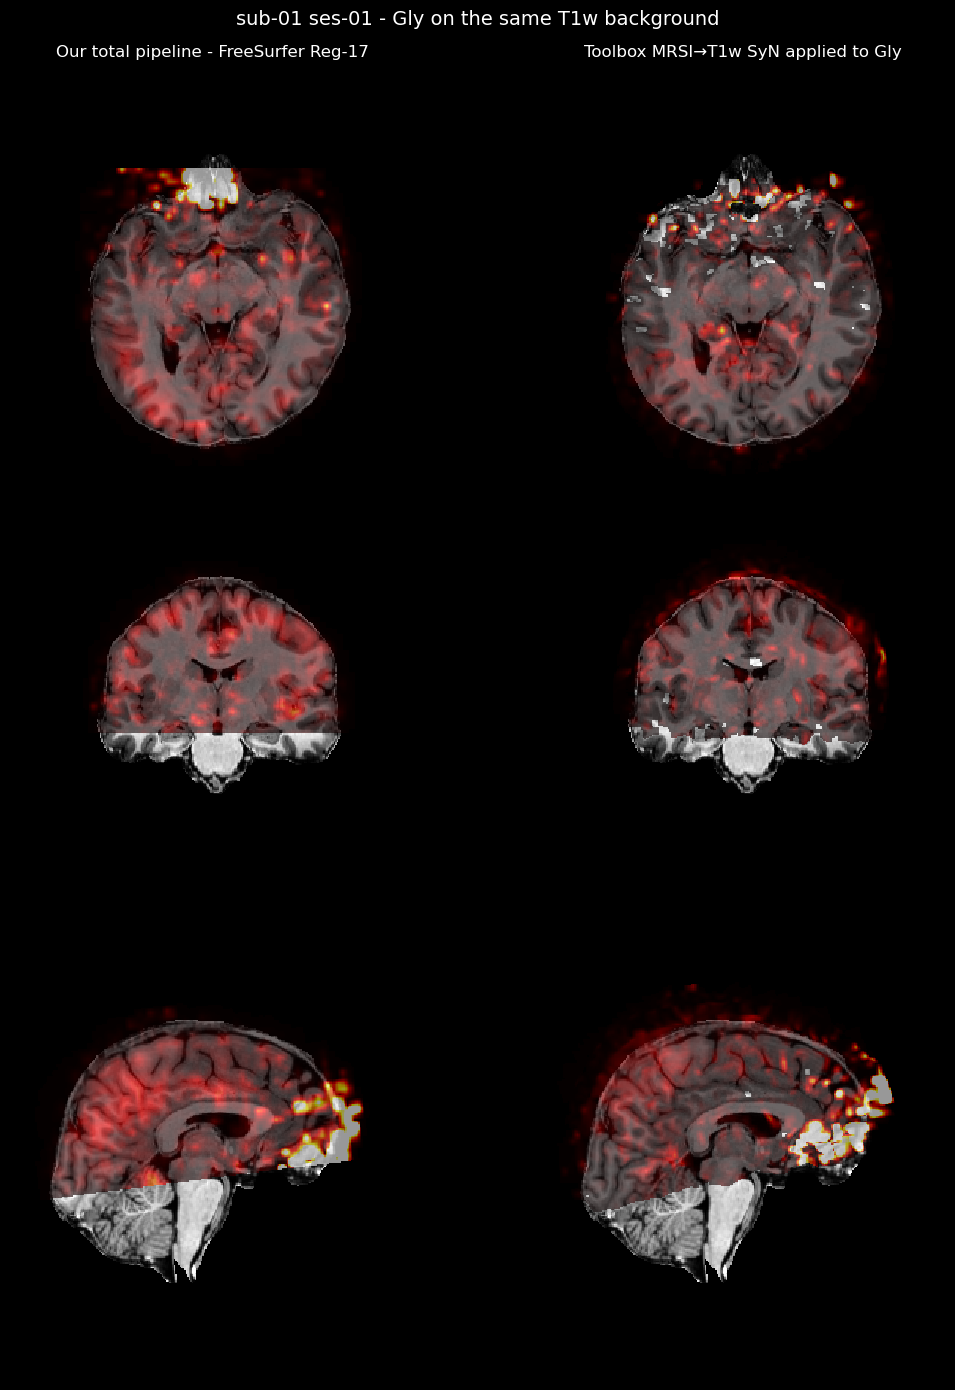

In [7]:
views = ['Axial', 'Coronal', 'Sagittal']
columns = [
    ('Our total pipeline - FreeSurfer Reg-17', fs_gly_data),
    ('Toolbox MRSI\u2192T1w SyN applied to Gly', toolbox_gly_data),
]

bg_slices = orthogonal_slices(background_data)
fig, axes = plt.subplots(3, 2, figsize=(12, 14), facecolor='black')

for col, (title, overlay_data) in enumerate(columns):
    overlay_slices = orthogonal_slices(overlay_data)
    for row, (bg_slice, overlay_slice) in enumerate(zip(bg_slices, overlay_slices)):
        ax = axes[row, col]
        ax.set_facecolor('black')
        ax.imshow(bg_slice.T, origin='lower', cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        masked_overlay = np.ma.masked_where(overlay_slice <= 1e-6, overlay_slice)
        ax.imshow(masked_overlay.T, origin='lower', cmap='hot', vmin=0, vmax=1, alpha=0.6, interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(title, color='white', fontsize=12)
        if col == 0:
            ax.set_ylabel(views[row], color='white', fontsize=11)

fig.suptitle('sub-01 ses-01 - Gly on the same T1w background', color='white', fontsize=14, y=0.99)
plt.tight_layout()

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
outpath = FIG_DIR / 'sub-01_gly_comparison_T1wres.png'
fig.savefig(outpath, dpi=150, bbox_inches='tight', facecolor='black')
print('Saved:', outpath)
plt.show()

## Native MRSI resolution comparison

Same comparison but **no upsampling** — the T1w background is down-sampled to the MRSI grid (74×74×37, ~3 mm isotropic) so every pixel in the overlay corresponds to one real MRSI voxel.

MRSI-res grid shape : (74, 74, 37)
Background (MRSI)   : (74, 74, 37)
Toolbox warp (MRSI) : (74, 74, 37)
Saved: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/figures/sub-01_gly_comparison_MRSIres.png


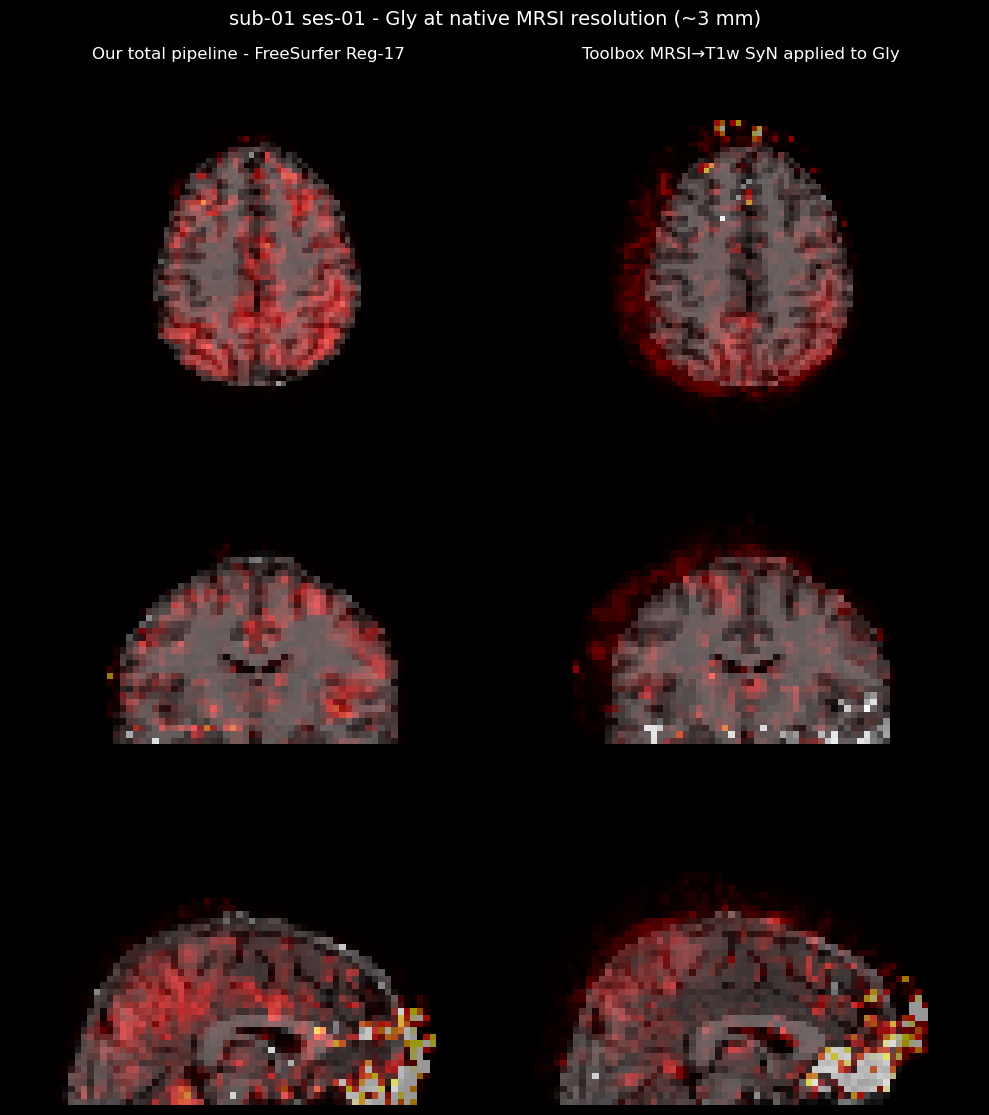

In [8]:
# ── MRSI-resolution comparison ───────────────────────────────────────────────
# Use the Reg-17 FSMask image (74x74x37, ~3 mm) as the reference grid.
# The T1w background is down-sampled to that grid; the toolbox Gly is warped
# to the same grid so both maps stay at native MRSI voxel size.

# Reference grid = FS Reg-17 output (T1w space, MRSI voxel size)
mrsi_ref_img = nib.as_closest_canonical(nib.load(str(FS_GLY_PATH)))

# Background T1w down-sampled to MRSI grid
bg_mrsi_img  = resample_from_to(background_img, mrsi_ref_img, order=1)
bg_mrsi_data = norm_image(bg_mrsi_img.get_fdata())

# Reg-17 FS Gly -- already at MRSI resolution, no resampling needed
fs_gly_mrsi_data = norm_image(mrsi_ref_img.get_fdata())

# Toolbox SyN Gly warped to MRSI-resolution grid
mrsi_fixed_ants = ants.image_read(str(FS_GLY_PATH))
toolbox_gly_mrsi_ants = ants.apply_transforms(
    fixed=mrsi_fixed_ants,
    moving=moving_ants,
    transformlist=[str(TOOLBOX_SYN), str(TOOLBOX_AFFINE)],
    interpolator='linear',
)
toolbox_gly_mrsi_data = norm_image(toolbox_gly_mrsi_ants.numpy().astype(np.float32))

print('MRSI-res grid shape :', mrsi_ref_img.shape)
print('Background (MRSI)   :', bg_mrsi_img.shape)
print('Toolbox warp (MRSI) :', toolbox_gly_mrsi_ants.shape)

# ── Plot ──────────────────────────────────────────────────────────────────────
views   = ['Axial', 'Coronal', 'Sagittal']
columns = [
    ('Our total pipeline - FreeSurfer Reg-17', fs_gly_mrsi_data),
    ('Toolbox MRSI\u2192T1w SyN applied to Gly',   toolbox_gly_mrsi_data),
]

bg_slices = orthogonal_slices(bg_mrsi_data)
fig2, axes2 = plt.subplots(3, 2, figsize=(10, 12), facecolor='black')

for col, (title, overlay_data) in enumerate(columns):
    overlay_slices = orthogonal_slices(overlay_data)
    for row, (bg_slice, overlay_slice) in enumerate(zip(bg_slices, overlay_slices)):
        ax = axes2[row, col]
        ax.set_facecolor('black')
        ax.imshow(bg_slice.T, origin='lower', cmap='gray', vmin=0, vmax=1,
                  interpolation='nearest')
        masked = np.ma.masked_where(overlay_slice <= 1e-6, overlay_slice)
        ax.imshow(masked.T, origin='lower', cmap='hot', vmin=0, vmax=1,
                  alpha=0.6, interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(title, color='white', fontsize=12)
        if col == 0:
            ax.set_ylabel(views[row], color='white', fontsize=11)

fig2.suptitle('sub-01 ses-01 - Gly at native MRSI resolution (~3 mm)',
              color='white', fontsize=14, y=0.99)
plt.tight_layout()

outpath2 = FIG_DIR / 'sub-01_gly_comparison_MRSIres.png'
fig2.savefig(outpath2, dpi=150, bbox_inches='tight', facecolor='black')
print('Saved:', outpath2)
plt.show()